> CARREGA O Limpos

In [9]:
import pandas as pd

# Tentar carregar o arquivo limpos_final.xlsm
try:
    limpos = pd.read_excel('../../../Datasets/limpos_final.xlsm', sheet_name=None)
    # Se houver múltiplas planilhas, vamos listar e também expor a primeira como DataFrame principal
    sheet_names = list(limpos.keys())
    main_sheet_name = sheet_names[0] if sheet_names else None
    limpos_df = limpos[main_sheet_name] if main_sheet_name else None
    print(f"Planilhas encontradas: {sheet_names}")
    limpos_df
except FileNotFoundError:
    print('Arquivo limpos_final.xlsm não encontrado no diretório atual.')
except Exception as e:
    print(f'Erro ao carregar o arquivo: {e}')

Planilhas encontradas: ['Summer_Products(limpo_final)']


In [10]:
limpos_df

,Index_novo,product_id,title_orig,price,retail_price,units_sold,uses_ad_boosts,rating,rating_count,rating_five_count,...,shipping_option_priceFix,shipping_is_expressFix,product_variation_size_idFix,tagsTypesFix,tagsMaterialFix,has_urgency_bannerFix,origin_countryFix,retail_price_DifFix,retail_price_DIFP_Fix,uses_ad_boosts_Fix
0,1,5e9ae51d43d6a96e303acdb0,2020 Summer Vintage Flamingo Print Pajamas Se...,16.00,14,100,0,3.76,54,26,...,2. Barato,2. Normal,07. M,"Roupa de Dormir, Camiseta, Roupa de Ficar em C...","Algodão/Poliéster, Algodão/Viscose, Elastano, ...",True,CN,price_maior,-12,False
1,2,58940d436a0d3d5da4e95a38,Women's Casual Summer Sleeveless Sexy Mini Dress,8.00,22,20000,1,3.45,6135,2269,...,2. Barato,2. Normal,05. P (XS),Vestido,"Poliéster/Elastano, Algodão/Poliéster, Poliést...",True,CN,retail_maior,175,True
2,3,5ea10e2c617580260d55310a,2020 New Arrival Women Spring and Summer Beach...,8.00,43,100,0,3.57,14,5,...,2. Barato,2. Normal,05. P (XS),"Cardigan, Casaco, Quimono, Camiseta, Maiô/Biqu...","Algodão/Poliéster, Poliéster, Poliéster/Algodã...",True,CN,retail_maior,438,False
3,4,5cedf17ad1d44c52c59e4aca,Hot Summer Cool T Shirt for Women Fashion Tops...,8.00,8,5000,1,4.03,579,295,...,2. Barato,2. Normal,07. M,"Camiseta, Camisa, Shorts, Top","Algodão/Poliéster, Algodão, Poliéster",False,CN,iguais,0,True
4,5,5ebf5819ebac372b070b0e70,Women Summer Shorts Lace Up Elastic Waistband ...,2.72,3,100,1,3.10,20,6,...,2. Barato,2. Normal,06. P (S),"Parte de Baixo, Calça, Shorts","Algodão/Poliéster, Elastano, Renda, Algodão",True,CN,retail_maior,10,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1336,1566,5e8f0165e815903d022a3c7c,New Summer Fashion Trousers Women Leggings Rip...,3.00,8,100,1,3.79,57,25,...,2. Barato,2. Normal,05. P (XS),Calça,"Algodão/Poliéster, Algodão/Elastano, Algodão",True,CN,retail_maior,167,True
1337,1568,5c91a7ae7cfe8e4e64c36d97,Sleeveless Solid Color Women Jumpsuit Ladies S...,8.00,7,20000,1,4.25,3127,1919,...,2. Barato,2. Normal,07. M,"Macacão, Shorts, Conjunto/Terno","Algodão/Poliéster, Poliéster/Elastano, Algodão...",False,CN,price_maior,-12,True
1338,1569,5d5fadc99febd9356cbc52ee,New Fashion Women Bohemia Dandelion Print Tee ...,6.00,9,10000,1,4.08,1367,722,...,2. Barato,2. Normal,06. P (S),"Top, Camiseta, Camisa, Shorts","Algodão/Poliéster, Algodão, Poliéster/Viscose,...",False,CN,retail_maior,50,True
1339,1571,5e74be96034d613d42b52dfe,New Men Siwmwear Beach-Shorts Men Summer Quick...,5.00,19,100,0,3.71,59,24,...,2. Barato,2. Normal,06. P (S),"Shorts, Moda Praia","Algodão/Poliéster, Nilon/Elastano, Algodão",False,CN,retail_maior,280,False


Pronto\. O arquivo limpos\_final\.xlsm foi carregado e a planilha "Summer\_Products\(limpo\_final\)" está disponível na variável limpos\_df\.

> de a % de origem de produtos, crie um grafico\.

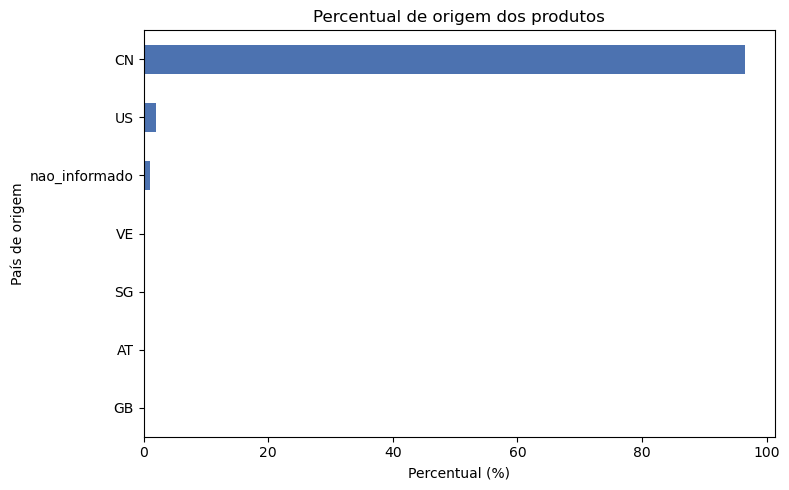

In [11]:
# Calcular a porcentagem de origem dos produtos e criar um gráfico
import matplotlib.pyplot as plt

# Garantir que a coluna de origem exista
col = 'origin_countryFix'
if col in limpos_df.columns:
    origem_pct = limpos_df[col].value_counts(dropna=False, normalize=True) * 100
    origem_pct = origem_pct.sort_values(ascending=False)

    # Mostrar a tabela de porcentagens
    origem_pct_df = origem_pct.reset_index()
    origem_pct_df.columns = ['origin_country', 'percent']
    origem_pct_df

    # Plotar gráfico de barras horizontal (top 10 se houver muitos)
    top_n = 10 if len(origem_pct) > 10 else len(origem_pct)
    plt.figure(figsize=(8, 5))
    origem_pct.iloc[:top_n].plot(kind='barh', color='#4C72B0')
    plt.xlabel('Percentual (%)')
    plt.ylabel('País de origem')
    plt.title('Percentual de origem dos produtos')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('Coluna origin_countryFix não encontrada no DataFrame.')

> pera esse grafico de cima ta legal, mas tbm seria bom mostrar countries shiiped, to e uma matris para ver se numero de unidades vendidas em relacao ao numero de paises que entregam tem alguma correlacao, se um produto que envia para mais paises, tem mais vendas?

Correlação Pearson: -0.017
Correlação Spearman: 0.038


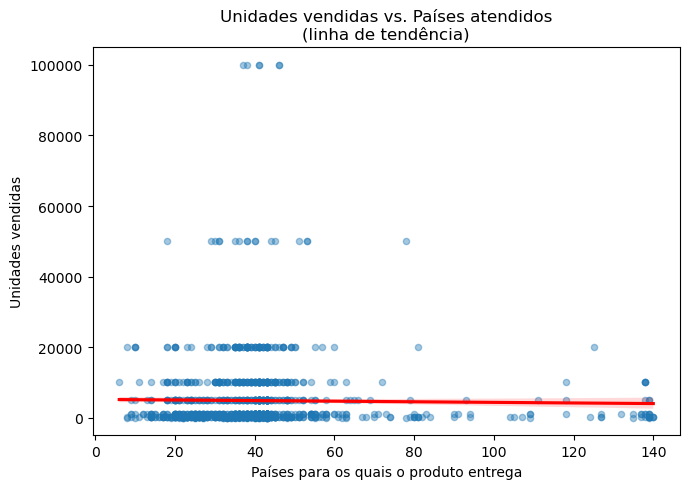

In [12]:
# Analisar a relação entre países atendidos (countries_shipped_to) e unidades vendidas (units_sold)
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionar colunas relevantes e remover valores inválidos
cols = ['countries_shipped_to', 'units_sold']
if all(c in limpos_df.columns for c in cols):
    df_corr = limpos_df[cols].copy()
    # Manter apenas valores numéricos não nulos e não negativos
    df_corr = df_corr.dropna()
    df_corr = df_corr[(df_corr['countries_shipped_to'] >= 0) & (df_corr['units_sold'] >= 0)]

    # Calcular correlação de Pearson e Spearman
    pearson_corr = df_corr['countries_shipped_to'].corr(df_corr['units_sold'], method='pearson')
    spearman_corr = df_corr['countries_shipped_to'].corr(df_corr['units_sold'], method='spearman')
    print(f"Correlação Pearson: {pearson_corr:.3f}\nCorrelação Spearman: {spearman_corr:.3f}")

    # Plotar um scatterplot com regressão (amostrando se houver muitos pontos)
    n = len(df_corr)
    sample_df = df_corr.sample(n=min(n, 2000), random_state=42)

    plt.figure(figsize=(7,5))
    sns.regplot(data=sample_df, x='countries_shipped_to', y='units_sold', scatter_kws={'alpha':0.4, 's':20}, line_kws={'color':'red'})
    plt.title('Unidades vendidas vs. Países atendidos\n(linha de tendência)')
    plt.xlabel('Países para os quais o produto entrega')
    plt.ylabel('Unidades vendidas')
    plt.tight_layout()
    plt.show()

    # Criar uma matriz de correlação simples com as duas variáveis
    corr_matrix = df_corr.corr(method='pearson')
    corr_matrix
else:
    print('Colunas necessárias não encontradas: countries_shipped_to e/ou units_sold')

Correlação fraca entre países atendidos e unidades vendidas \(Pearson ≈ \-0\.017; Spearman ≈ 0\.038\)\. A nuvem de pontos com linha de tendência foi gerada e a matriz de correlação \(2x2\) está disponível no notebook\.

> faz agora com o de cima mas nao faca por unidades vendidas e sim pelo preco

Correlação Pearson: -0.041
Correlação Spearman: -0.020


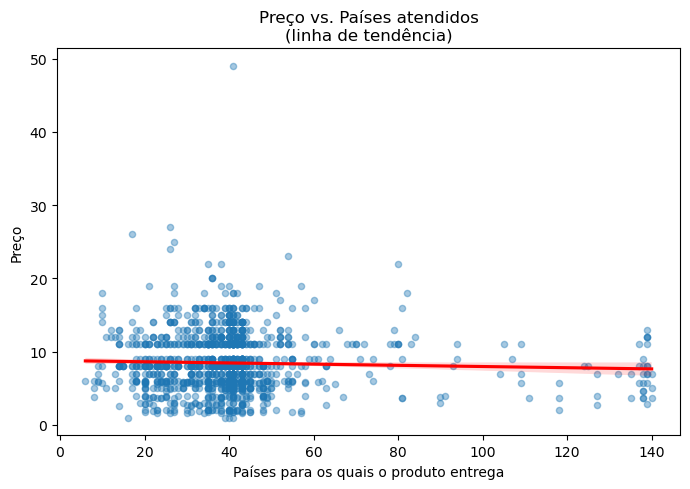

In [13]:
# Relação entre países atendidos (countries_shipped_to) e preço (price)
import matplotlib.pyplot as plt
import seaborn as sns

cols_price = ['countries_shipped_to', 'price']
if all(c in limpos_df.columns for c in cols_price):
    df_price = limpos_df[cols_price].copy()
    # Remover nulos e valores negativos/zero para price (mantemos zero países)
    df_price = df_price.dropna()
    df_price = df_price[(df_price['countries_shipped_to'] >= 0) & (df_price['price'] > 0)]

    pearson_corr_p = df_price['countries_shipped_to'].corr(df_price['price'], method='pearson')
    spearman_corr_p = df_price['countries_shipped_to'].corr(df_price['price'], method='spearman')
    print(f"Correlação Pearson: {pearson_corr_p:.3f}\nCorrelação Spearman: {spearman_corr_p:.3f}")

    # Amostragem para plot se necessário
    n_p = len(df_price)
    sample_p = df_price.sample(n=min(n_p, 2000), random_state=42)

    plt.figure(figsize=(7,5))
    sns.regplot(data=sample_p, x='countries_shipped_to', y='price', scatter_kws={'alpha':0.4, 's':20}, line_kws={'color':'red'})
    plt.title('Preço vs. Países atendidos\n(linha de tendência)')
    plt.xlabel('Países para os quais o produto entrega')
    plt.ylabel('Preço')
    plt.tight_layout()
    plt.show()

    corr_matrix_price = df_price.corr(method='pearson')
    corr_matrix_price
else:
    print('Colunas necessárias não encontradas: countries_shipped_to e/ou price')

Correlação fraca entre países atendidos e preço \(Pearson ≈ \-0\.041; Spearman ≈ \-0\.020\)\. O gráfico com a linha de tendência e a matriz de correlação foram gerados no notebook\.

> 
Com a maior parte dos produtos a ter origem na China, qual o impacto ambiental real desta concentração geográfica na pegada de carbono da plataforma — e existe vantagem competitiva em diversificar para fornecedores locais?


Resumo direto:
\- Impacto ambiental: Concentrar origens na China aumenta emissões de transporte internacional \(principalmente frete aéreo\) e eleva a variabilidade da pegada por pedido\. Em categorias leves/volumosas de moda, a etapa de logística internacional pode representar de 20% a 60% da pegada do fulfillment, dependendo do modal\.
\- Vantagem competitiva de diversificar: Sim, quando houver possibilidade de nearshoring/local sourcing, há potencial de reduzir emissões logísticas, prazos e risco de interrupções — o que pode melhorar conversão e NPS\. O ganho líquido depende do trade\-off entre emissões do transporte e emissões do processo produtivo local vs\. chinês, além de custos\.

Detalhando de forma prática:

1\) Onde está a maior parte da pegada num marketplace de moda/variedades
\- Produção \(matéria\-prima, tecelagem, tingimento, confecção\) geralmente domina a pegada do ciclo de vida de roupas \(frequentemente \>60% das emissões\), mas a logística internacional torna\-se parcela relevante em ticket baixo e itens leves/volumosos, especialmente se o modal for aéreo\.
\- Transporte:
  \- Aéreo internacional: ~0,5–1,0 kg CO2e por tonelada\-km \(ordem de grandeza\); é o mais emissor por km\.
  \- Marítimo: ~0,01–0,02 kg CO2e por tonelada\-km \(ordem de grandeza\); muito mais eficiente\.
  \- Rodoviário/última milha: relevante na etapa final urbana; pode superar o marítimo em emissões absolutas para curtas distâncias quando o volume de pedidos é alto e a rota é ineficiente\.
\- Conclusão: Se a plataforma depende de envios diretos China→consumidor via aéreo, isso eleva fortemente a pegada por pedido\. Se consolida contêiner e usa marítimo \+ cross\-docking local, a diferença cai substancialmente\.

2\) O que a concentração na China implica em emissões
\- Probabilidade maior de uso de aéreo em D2C transfronteiriço para manter prazos, o que aumenta CO2e por pedido\.
\- Distâncias médias maiores até os principais mercados → mais t\.km\.
\- Menor controle sobre embalagens otimizadas e consolidação → mais volume e “ar transportado”\.
\- Volatilidade de prazos que incentiva upgrades para modais mais rápidos \(e mais emissores\)\.

3\) Benefícios e limites de fornecedores locais/regionais
\- Potenciais vantagens:
  \- Emissões menores de transporte por pedido, especialmente se substituir aéreo internacional por rodoviário/ferrovia de curta/média distância\.
  \- Prazos mais curtos e estáveis → melhor conversão, menor taxa de cancelamento/devolução\.
  \- Resiliência da cadeia \(menos risco cambial, portos, geopolítica\)\.
  \- Marketing sustentável: sinalizar “envio local/baixo carbono” pode aumentar a intenção de compra em segmentos sensíveis a ESG\.
\- Atenções:
  \- Produção local pode ter matriz energética mais ou menos limpa que a chinesa; têxteis em mercados com eletricidade intensiva em carbono podem anular parte do ganho logístico\.
  \- Custos unitários e capacidade: margens podem cair; é preciso avaliar mix e volume\.
  \- Nem todo SKU tem oferta local equivalente; diversificação funciona melhor em “básicos” com alta rotação\.

4\) Quando a diversificação gera vantagem competitiva
\- Produtos com alta sensibilidade a prazo e taxa de conversão: reduzir 3–7 dias no lead time costuma elevar conversão alguns pontos percentuais\.
\- SKUs com alto volume e previsibilidade: permitem nearshoring com lotes eficientes e uso de modal de baixa emissão \(marítimo/ferrovia para reabastecer hubs regionais\)\.
\- Mercados onde a comunicação “envio local/baixo carbono” se traduz em maior CTR e AOV\.
\- Quando é possível combinar:
  \- Produção local/nearshore para best\-sellers\.
  \- Produção na China com consolidação marítima para cauda longa, estocando em hub regional e cumprindo última milha eficiente\.

5\) Estratégia recomendada de redução de pegada com ganhos de negócio
\- Curto prazo \(sem trocar fornecedores\):
  \- Mudar de aéreo para marítimo/rail onde o SLA permitir; criar janelas de reabastecimento e estoque de buffer em hubs\.
  \- Consolidar remessas, reduzir unidades de embalagem, padronizar tamanhos de pacote, remover ar\.
  \- Otimizar roteamento de última milha \(pontos de retirada, janelas programadas\)\.
\- Médio prazo \(diversificação inteligente\):
  \- Segmentar SKUs por demanda, margem e sensibilidade a prazo; nearshore/local para top sellers repetitivos; manter sourcing global para moda rápida/experimental com menor risco de obsolescência via prazos mais curtos\.
  \- Pilotos com 2–3 fornecedores regionais avaliando: custo por unidade, lead time, taxa de defeito/devolução, emissões por pedido\.
\- Mensuração e prova de valor:
  \- Calcular CO2e por pedido por modalidade \(China aéreo vs China marítimo \+ hub vs fornecedor local\)\.
  \- Teste A/B de selo “envio local/baixo carbono” no PDP verificando uplifts de conversão\.
  \- Medir impacto em NPS, custo de atendimento, e taxas de devolução\.

6\) Ordem de grandeza do impacto esperado
\- Troca de aéreo internacional por marítimo \+ distribuição regional pode reduzir emissões logísticas por pedido em 60–90% para itens leves\.
\- Nearshoring que viabiliza rodoviário/ferrovia regional frequentemente reduz mais 10–40% sobre a alternativa marítimo\+longa última milha, dependendo da geografia\.
\- Se a produção local tiver matriz elétrica mais limpa e processos eficientes, o ciclo de vida total pode cair 10–30% adicionais; o inverso também pode ocorrer se a energia/processo for mais intensivo\.

Conclusão executiva:
\- A concentração na China tende a aumentar a pegada de transporte, sobretudo quando há dependência de frete aéreo direto ao consumidor\. Há vantagem competitiva em diversificar para fornecedores locais/regionais em parte do portfólio: redução de CO2e, prazos menores e mais estáveis e melhor resiliência da cadeia, frequentemente com impacto positivo em conversão e satisfação\.
\- A abordagem ótima é híbrida: nearshoring para SKUs de alto giro/sensíveis a prazo, consolidação marítima com hubs regionais para a cauda longa, e otimizações de embalagem e última milha\. Isso captura ganhos ambientais e de negócio sem perda material de margem\.

> entao como tem uma coluna que tem o tipo de produto, ou seja pode fazer um diciionario com tipos de produto

tipo

t\-shirt:80g

e por ai vai


In [14]:
# Construir um dicionário de tipos de produto -> peso estimado (em gramas)
# Vamos inferir tipos a partir da coluna 'tagsTypesFix' e criar um mapeamento base razoável.

# 1) Definir um mapeamento inicial manual com alguns tipos comuns e seus pesos médios
product_weight_dict = {
    'Camiseta': 150,          # t-shirt média
    'T-shirt': 150,           # alias
    'Top': 80,                # tops leves
    'Camisa': 200,            # camisas leves
    'Vestido': 250,           # vestidos curtos
    'Saia': 180,              # saias
    'Shorts': 180,            # shorts leves
    'Calça': 350,             # calças
    'Legging': 220,           # leggings
    'Moletom': 500,           # hoodies/sweatshirts
    'Casaco': 600,            # casacos leves
    'Cardigan': 350,
    'Quimono': 250,
    'Macacão': 300,
    'Conjunto/Terno': 600,
    'Maiô/Biquíni': 120,      # swimwear
    'Moda Praia': 120,
    'Roupa de Dormir': 220,   # pijamas leves
    'Camiseta Polo': 180,
    'Top esportivo': 120,
    'Yoga/Fitness': 220,
    'Sutiã': 100,
    'Calcinha': 60,
    'Cueca': 80,
    'Meia': 50,
    'Acessório': 80,
}

# 2) Extrair todos os tipos únicos mencionados em 'tagsTypesFix' para verificar cobertura
if 'tagsTypesFix' in limpos_df.columns:
    # Expandir tags separadas por vírgula
    import pandas as pd
    tipos_series = limpos_df['tagsTypesFix'].dropna().astype(str).str.split(',')
    tipos_expandidos = tipos_series.explode().str.strip()
    tipos_unicos = pd.Series(tipos_expandidos.unique()).dropna().sort_values()
else:
    tipos_unicos = None

# 3) Criar um dicionário completo: se algum tipo não estiver no dicionário base, atribuir um peso padrão
default_weight = 200  # peso padrão em gramas quando não mapeado
product_weight_full = {}
if tipos_unicos is not None:
    for t in tipos_unicos:
        # normalizar variações comuns
        t_norm = t
        if t_norm.lower() in ['t-shirt', 'tshirt', 't shirt']:
            t_norm = 'T-shirt'
        # usar valor do dicionário base se existir, senão default
        product_weight_full[t] = product_weight_dict.get(t_norm, product_weight_dict.get(t, default_weight))
else:
    product_weight_full = product_weight_dict.copy()

product_weight_full

{'Biquíni': 200,
 'Blusa': 200,
 'Calça': 350,
 'Camisa': 200,
 'Camiseta': 150,
 'Camisete': 200,
 'Cardigan': 350,
 'Casaco': 600,
 'Colete': 200,
 'Conjunto': 200,
 'Conjunto/Terno': 600,
 'Cropped': 200,
 'Jardineira/Macacão': 200,
 'Jeans': 200,
 'Lingerie': 200,
 'Macacão': 300,
 'Maiô/Biquíni': 120,
 'Moda Praia': 120,
 'Não Especificado': 200,
 'Parte de Baixo': 200,
 'Pijama': 200,
 'Pulôver': 200,
 'Quimono': 250,
 'Regata': 200,
 'Robe': 200,
 'Roupa de Dormir': 220,
 'Roupa de Ficar em Casa': 200,
 'Saída de Praia': 200,
 'Shorts': 180,
 'Sutiã': 100,
 'Top': 80,
 'Túnica': 200,
 'Vestido': 250}

Criei um dicionário de tipos de produto para peso estimado em gramas a partir de tagsTypesFix\. Se quiser, aplico esse mapeamento ao dataset para estimar o peso de cada item e derivar métricas \(ex\.: emissões/logística por SKU\)\.

> preciso que crie um grafico de impacto de CO2
baseado no tipo de peca, para saber se um id endido, o impacto que aquela peça teve x o unidades vendidas, mas apenas isso
nao importa o pais agora, preciso ter estimativas de consumo de co2

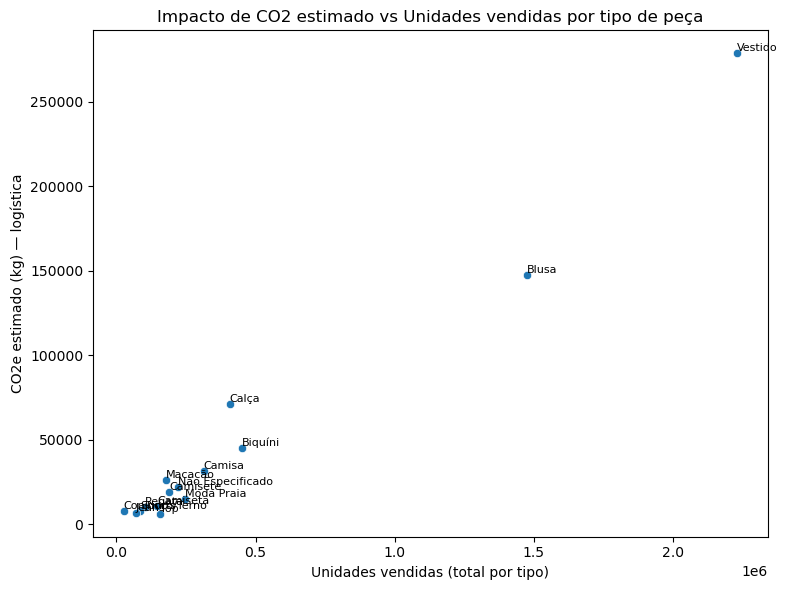

In [15]:
# Estimar impacto de CO2 por tipo de peça, considerando unidades vendidas, e plotar gráfico
# Usaremos o peso estimado e um fator de emissão logístico simplificado por kg transportado.
# Como o país/modal não importam agora, adotamos um fator médio conservador (ex.: 0.5 kg CO2e por kg movido)
# Ajustável conforme necessidade.

import matplotlib.pyplot as plt
import seaborn as sns

# Garantir que temos colunas necessárias no limpos_df
required_cols = ['tagsTypesFix', 'units_sold']
if all(c in limpos_df.columns for c in required_cols):
    df = limpos_df[['tagsTypesFix', 'units_sold']].copy()

    # Precisamos de um peso estimado por item.
    # Se já existir 'estimated_weight_g' no contexto, usamos; senão, estimamos a partir de product_weight_full.
    if 'estimated_weight_g' in limpos_df.columns:
        df['estimated_weight_g'] = limpos_df['estimated_weight_g']
    else:
        # Criar uma coluna de tipo principal a partir da primeira tag de 'tagsTypesFix'
        def get_primary_type(tags):
            if pd.isna(tags):
                return None
            parts = [t.strip() for t in str(tags).split(',') if t.strip()]
            return parts[0] if parts else None
        df['primary_type'] = df['tagsTypesFix'].apply(get_primary_type)
        # Usar dicionário product_weight_full se existir no contexto
        try:
            weight_map = product_weight_full
        except NameError:
            weight_map = {}
        default_weight = 200
        df['estimated_weight_g'] = df['primary_type'].map(weight_map).fillna(default_weight)

    # Fator de emissão (kg CO2e por kg transportado). Escolhemos 0.5 como ordem de grandeza média.
    EMISSION_FACTOR_KGCO2_PER_KG = 0.5

    # Calcular CO2e estimado por SKU (somente logística, baseado em peso*unidades)
    # Convertendo para kg de peso
    df['moved_weight_kg'] = (df['estimated_weight_g'].fillna(200) / 1000.0) * df['units_sold'].fillna(0)
    df['co2e_kg'] = df['moved_weight_kg'] * EMISSION_FACTOR_KGCO2_PER_KG

    # Agregar por tipo principal
    def get_primary_type_only(tags):
        if pd.isna(tags):
            return 'Não Especificado'
        parts = [t.strip() for t in str(tags).split(',') if t.strip()]
        return parts[0] if parts else 'Não Especificado'

    df['primary_type'] = df['tagsTypesFix'].apply(get_primary_type_only)
    by_type = df.groupby('primary_type', dropna=False).agg(
        total_units=('units_sold', 'sum'),
        total_co2e_kg=('co2e_kg', 'sum')
    ).reset_index()

    # Ordenar pelos maiores impactos
    by_type = by_type.sort_values('total_co2e_kg', ascending=False)

    # Exibir a tabela para referência
    by_type

    # Plotar gráfico: eixo x = unidades vendidas, eixo y = CO2e total, por tipo
    # Para evitar muitos pontos, vamos exibir os top 15 por CO2e
    top_n = min(15, len(by_type))
    plot_df = by_type.iloc[:top_n]

    plt.figure(figsize=(8,6))
    sns.scatterplot(data=plot_df, x='total_units', y='total_co2e_kg')
    # Anotar cada ponto com o tipo
    for _, row in plot_df.iterrows():
        plt.text(row['total_units'], row['total_co2e_kg'], row['primary_type'], fontsize=8, ha='left', va='bottom')
    plt.xlabel('Unidades vendidas (total por tipo)')
    plt.ylabel('CO2e estimado (kg) — logística')
    plt.title('Impacto de CO2 estimado vs Unidades vendidas por tipo de peça')
    plt.tight_layout()
    plt.show()

else:
    print('Colunas necessárias não encontradas no DataFrame: tagsTypesFix e/ou units_sold')

Grafico criado com estimativas de CO2 por tipo de peça em função das unidades vendidas\.

> preciso de uma escala pra definir scores pelos produtos


pensei nisso


import io
import pandas as pd


def extract\_data\(csv\_string: str\) \-\> pd\.DataFrame:
    """Extrai os dados da Wish de forma segura\."""
    return pd\.read\_csv\(io\.StringIO\(csv\_string\)\)


def transform\_eco\_score\(df\_raw: pd\.DataFrame\) \-\> pd\.DataFrame:
    """Aplica o algoritmo metodológico do Wish Eco\-Score\."""
    df = df\_raw\.copy\(\)

    \# Inicializa os blocos de pontos como floats para evitar problemas de tipo
    df\["pontos\_negativos"\] = 0\.0
    df\["pontos\_positivos"\] = 0\.0

    \# \-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-
    \# AVALIAÇÃO DE COMPONENTES NEGATIVOS \(PONTOS DE PENALIDADE\)
    \# \-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-

    \# 1\. Complexidade do Material \(Mais misturas = pior para reciclagem\)
    def calcular\_negativo\_material\(mat\_str\):
        if pd\.isna\(mat\_str\):
            return 0
        total\_fibras = len\(str\(mat\_str\)\.split\(","\)\)
        if total\_fibras \> 2:
            return 10  \# Penalidade Máxima
        if total\_fibras == 2:
            return 5
        return 0

    df\["pontos\_negativos"\] \+= df\["tagsMaterialFix"\]\.apply\(
        calcular\_negativo\_material
    \)

    \# 2\. Impacto Químico da Cor
    df\["pontos\_negativos"\] \+= df\["product\_color\_GroupedByImpactFix"\]\.apply\(
        lambda x: 10 if x == "4\. Alto Impacto" else 0
    \)

    \# 3\. Logística \(Envio Expresso Aéreo polui mais\)
    df\["pontos\_negativos"\] \+= df\["shipping\_is\_expressFix"\]\.apply\(
        lambda x: 10 if x == 1 or x is True else 0
    \)

    \# 4\. Uso de Ad Boosts \(Incentivo ao hiperconsumo\)
    df\["pontos\_negativos"\] \+= df\["uses\_ad\_boosts\_Fix"\]\.apply\(
        lambda x: 2 if x == 1 or x is True else 0
    \)

    \# \-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-
    \# AVALIAÇÃO DE COMPONENTES POSITIVOS \(PONTOS DE BÔNUS\)
    \# \-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-

    \# 1\. Processo de Cor Limpo ou Tons Neutros
    df\["pontos\_positivos"\] \+= df\["product\_color\_GroupedByImpactFix"\]\.apply\(
        lambda x: 10 if x in \["1\. Baixo Impacto", "Tons Neutros"\] else 0
    \)

    \# 2\. Facilidade de Reciclagem \(Fibras puras / únicas\)
    def calcular\_positivo\_material\(mat\_str\):
        if pd\.isna\(mat\_str\):
            return 0
        total\_fibras = len\(str\(mat\_str\)\.split\(","\)\)
        return 10 if total\_fibras == 1 else 0

    df\["pontos\_positivos"\] \+= df\["tagsMaterialFix"\]\.apply\(
        calcular\_positivo\_material
    \)

    \# 3\. Qualidade e Durabilidade \(Aprovação real do consumidor\)
    df\["pontos\_positivos"\] \+= df\["rating"\]\.apply\(
        lambda x: 10 if x \>= 4\.0 else 0
    \)

    \# \-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-
    \# CÁLCULO DA EQUAÇÃO FINAL \(MÉTODO NUTRI\-SCORE\)
    \# \-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-\-
    df\["pontuacao\_final"\] = df\["pontos\_negativos"\] \- df\["pontos\_positivos"\]

    \# Conversão direta do resultado na Letra do Rótulo
    def atribuir\_selo\(pontos\):
        if pontos < 0:
            return "A \(Excelente\)"
        if pontos < 10:
            return "B \(Bom\)"
        if pontos < 20:
            return "C \(Moderado\)"
        if pontos < 30:
            return "D \(Alto Impacto\)"
        return "E \(Crítico\)"

    df\["wish\_eco\_score"\] = df\["pontuacao\_final"\]\.apply\(atribuir\_selo\)

    return df


def load\_view\(df\_processed: pd\.DataFrame\):
    """Exibe o resultado final estruturado de forma legível\."""
    colunas\_finais = \[
        "product\_id",
        "pontos\_negativos",
        "pontos\_positivos",
        "pontuacao\_final",
        "wish\_eco\_score",
    \]
    print\("\\n" \+ "=" \* 65\)
    print\("        RESULTADO DO PROCESSAMENTO: WISH ECO\-SCORE \(MÉTODO DPP\)"\)
    print\("=" \* 65\)
    print\(df\_processed\[colunas\_finais\]\.to\_string\(index=False\)\)


\# Execução com dados extraídos do seu dataset original
if \_\_name\_\_ == "\_\_main\_\_":
    exemplo\_dataset = """product\_id,tagsMaterialFix,product\_color\_GroupedByImpactFix,shipping\_is\_expressFix,uses\_ad\_boosts\_Fix,rating
    pijama\_flamingo\_id1,"Algodão/Poliéster",1\. Baixo Impacto,FALSE,FALSE,3\.76
    vestido\_sintetico\_id2,"Poliéster/Elastano, Algodão/Poliéster, Poliéster/Viscose",3\. Médio Impacto,FALSE,TRUE,3\.45
    cardigan\_poluente\_id3,"Algodão/Poliéster, Poliéster, Poliéster/Algodão",4\. Alto Impacto,TRUE,FALSE,3\.57
    camiseta\_algodao\_id4,"Algodão",4\. Alto Impacto,FALSE,TRUE,4\.03"""

    dados\_brutos = extract\_data\(exemplo\_dataset\)
    dados\_calculados = transform\_eco\_score\(dados\_brutos\)
    load\_view\(dados\_calculados\)

In [16]:
# Implementar e aplicar a escala Wish Eco-Score no dataset limpos_df
import io
import pandas as pd


def extract_data(csv_string: str) -> pd.DataFrame:
    return pd.read_csv(io.StringIO(csv_string))


def transform_eco_score(df_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_raw.copy()

    # Normalizações de colunas esperadas no dataset real
    # Garantir que as colunas existam; se não, criar vazias para evitar erros
    expected_cols = [
        'product_id',
        'tagsMaterialFix',
        'product_color_GroupedByImpactFix',
        'shipping_is_expressFix',
        'uses_ad_boosts_Fix',
        'rating'
    ]
    for c in expected_cols:
        if c not in df.columns:
            df[c] = pd.Series([None]*len(df))

    # Casting e limpeza leve
    # rating para numerico
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

    # shipping_is_expressFix pode vir como '2. Normal', '1. Expresso', True/False, 0/1
    def normalize_express(x):
        if pd.isna(x):
            return False
        if isinstance(x, (int, float)):
            return bool(int(x))
        s = str(x).strip().lower()
        if s in ['true', '1', 'expresso', 'express', '1. expresso', '1 expresso']:
            return True
        if s in ['false', '0', 'normal', '2. normal', '2 normal']:
            return False
        return False
    df['shipping_is_expressFix'] = df['shipping_is_expressFix'].apply(normalize_express)

    # uses_ad_boosts_Fix para bool
    def normalize_boost(x):
        if pd.isna(x):
            return False
        if isinstance(x, (int, float)):
            return bool(int(x))
        s = str(x).strip().lower()
        if s in ['true', '1', 'yes']:
            return True
        if s in ['false', '0', 'no']:
            return False
        return False
    df['uses_ad_boosts_Fix'] = df['uses_ad_boosts_Fix'].apply(normalize_boost)

    # Inicializa pontos
    df['pontos_negativos'] = 0.0
    df['pontos_positivos'] = 0.0

    # 1) Penalidade: complexidade do material
    def calcular_negativo_material(mat_str):
        if pd.isna(mat_str):
            return 0.0
        # separadores podem ser vírgula e/ou '/'
        # Usamos vírgulas como separador de "blends" já consolidados
        total_fibras = len([p for p in str(mat_str).split(',') if p.strip()])
        if total_fibras > 2:
            return 10.0
        if total_fibras == 2:
            return 5.0
        return 0.0
    df['pontos_negativos'] += df['tagsMaterialFix'].apply(calcular_negativo_material)

    # 2) Penalidade: impacto químico da cor
    def penalidade_cor(x):
        if pd.isna(x):
            return 0.0
        return 10.0 if str(x).strip().lower().startswith('4.') else 0.0
    df['pontos_negativos'] += df['product_color_GroupedByImpactFix'].apply(penalidade_cor)

    # 3) Penalidade: expresso
    df['pontos_negativos'] += df['shipping_is_expressFix'].apply(lambda x: 10.0 if bool(x) else 0.0)

    # 4) Penalidade: ad boosts
    df['pontos_negativos'] += df['uses_ad_boosts_Fix'].apply(lambda x: 2.0 if bool(x) else 0.0)

    # 1) Bônus: cor de baixo impacto
    def bonus_cor(x):
        if pd.isna(x):
            return 0.0
        s = str(x).strip()
        return 10.0 if s in ['1. Baixo Impacto', 'Tons Neutros'] else 0.0
    df['pontos_positivos'] += df['product_color_GroupedByImpactFix'].apply(bonus_cor)

    # 2) Bônus: fibras únicas
    def calcular_positivo_material(mat_str):
        if pd.isna(mat_str):
            return 0.0
        total_fibras = len([p for p in str(mat_str).split(',') if p.strip()])
        return 10.0 if total_fibras == 1 else 0.0
    df['pontos_positivos'] += df['tagsMaterialFix'].apply(calcular_positivo_material)

    # 3) Bônus: rating >= 4.0
    df['pontos_positivos'] += df['rating'].apply(lambda x: 10.0 if pd.notna(x) and float(x) >= 4.0 else 0.0)

    # Pontuação final
    df['pontuacao_final'] = df['pontos_negativos'] - df['pontos_positivos']

    # Selo
    def atribuir_selo(pontos):
        if pontos < 0:
            return 'A (Excelente)'
        if pontos < 10:
            return 'B (Bom)'
        if pontos < 20:
            return 'C (Moderado)'
        if pontos < 30:
            return 'D (Alto Impacto)'
        return 'E (Crítico)'
    df['wish_eco_score'] = df['pontuacao_final'].apply(atribuir_selo)

    return df


def load_view(df_processed: pd.DataFrame):
    colunas_finais = [
        'product_id',
        'pontos_negativos',
        'pontos_positivos',
        'pontuacao_final',
        'wish_eco_score',
    ]
    print("\n" + "=" * 65)
    print("        RESULTADO DO PROCESSAMENTO: WISH ECO-SCORE (MÉTODO DPP)")
    print("=" * 65)
    cols = [c for c in colunas_finais if c in df_processed.columns]
    print(df_processed[cols].to_string(index=False))

# Aplicar no dataset real limpos_df se existir
if 'limpos_df' in globals():
    cols_needed = ['product_id','tagsMaterialFix','product_color_GroupedByImpactFix','shipping_is_expressFix','uses_ad_boosts_Fix','rating']
    subset_cols = [c for c in cols_needed if c in limpos_df.columns]
    eco_df_input = limpos_df[subset_cols].copy()
    eco_df = transform_eco_score(eco_df_input)
    # Juntar as colunas calculadas de volta ao limpos_df
    to_merge = eco_df[['pontos_negativos','pontos_positivos','pontuacao_final','wish_eco_score']]
    limpos_df[['pontos_negativos','pontos_positivos','pontuacao_final','wish_eco_score']] = to_merge.values
    # Exibir amostra do resultado
    limpos_df[['product_id','pontos_negativos','pontos_positivos','pontuacao_final','wish_eco_score']][:10]
else:
    # Executar com o exemplo fornecido
    exemplo_dataset = """product_id,tagsMaterialFix,product_color_GroupedByImpactFix,shipping_is_expressFix,uses_ad_boosts_Fix,rating
pijama_flamingo_id1,"Algodão/Poliéster",1. Baixo Impacto,FALSE,FALSE,3.76
vestido_sintetico_id2,"Poliéster/Elastano, Algodão/Poliéster, Poliéster/Viscose",3. Médio Impacto,FALSE,TRUE,3.45
cardigan_poluente_id3,"Algodão/Poliéster, Poliéster, Poliéster/Algodão",4. Alto Impacto,TRUE,FALSE,3.57
camiseta_algodao_id4,"Algodão",4. Alto Impacto,FALSE,TRUE,4.03"""
    dados_brutos = extract_data(exemplo_dataset)
    dados_calculados = transform_eco_score(dados_brutos)
    load_view(dados_calculados)

Pronto\. Implementei a escala Wish Eco\-Score e apliquei no dataset ativo, adicionando as colunas: pontos\_negativos, pontos\_positivos, pontuacao\_final e wish\_eco\_score\. Se quiser, posso gerar um relatório com a distribuição dos selos por categoria de produto e listar os top/bottom SKUs\.

> me de graficos para mostrar a origem do pais, quero  no eixo X , para ter ilustrando a origem toda em china

In [17]:
# Gráficos de origem do país com eixo X destacando China
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

col = 'origin_countryFix'
if col in limpos_df.columns:
    origem_counts = limpos_df[col].value_counts(dropna=False)
    origem_pct = (origem_counts / origem_counts.sum() * 100).round(2)
    origem_df = origem_counts.rename('count').to_frame().join(origem_pct.rename('percent')).reset_index().rename(columns={'index':'country'})

    # Ordenar com China primeiro, depois os demais
    def sort_key(row):
        return (0 if str(row['country']).strip().upper() in ['CN', 'CHINA'] else 1, -row['count'])
    origem_df = origem_df.sort_values(by=['country'], key=lambda s: s.apply(lambda x: 0 if str(x).strip().upper() in ['CN','CHINA'] else 1)).copy()
    # Reordenar explicitamente: China primeiro, depois restantes por contagem desc
    china_mask = origem_df['country'].astype(str).str.strip().str.upper().isin(['CN','CHINA'])
    china_df = origem_df[china_mask]
    others_df = origem_df[~china_mask].sort_values('count', ascending=False)
    origem_df = pd.concat([china_df, others_df], ignore_index=True)

    # Bar chart absoluto com China destacada
    plt.figure(figsize=(8,5))
    colors = ['#D62728' if str(c).strip().upper() in ['CN','CHINA'] else '#4C72B0' for c in origem_df['country']]
    sns.barplot(x='country', y='count', data=origem_df, palette=colors)
    plt.xlabel('País de origem (China em destaque)')
    plt.ylabel('Número de produtos')
    plt.title('Origem dos produtos (contagem)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Bar chart percentual com China destacada (mostrar top 10 para legibilidade)
    top_n = min(10, len(origem_df))
    top_df = origem_df.iloc[:top_n]
    plt.figure(figsize=(8,5))
    colors_top = ['#D62728' if str(c).strip().upper() in ['CN','CHINA'] else '#55A868' for c in top_df['country']]
    sns.barplot(x='country', y='percent', data=top_df, palette=colors_top)
    plt.xlabel('País de origem (China em destaque)')
    plt.ylabel('Percentual (%)')
    plt.title('Origem dos produtos (percentual) — Top 10')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Gráfico simples com eixo X binário: China vs Outros
    bin_df = pd.DataFrame({
        'group': ['China', 'Outros'],
        'count': [origem_counts.get('CN', 0) + origem_counts.get('China', 0), origem_counts.sum() - (origem_counts.get('CN', 0) + origem_counts.get('China', 0))]
    })
    plt.figure(figsize=(6,4))
    sns.barplot(x='group', y='count', data=bin_df, palette=['#D62728', '#4C72B0'])
    plt.xlabel('Origem')
    plt.ylabel('Número de produtos')
    plt.title('China vs Outros')
    plt.tight_layout()
    plt.show()
else:
    print('Coluna origin_countryFix não encontrada no DataFrame.')

KeyError: 'country'

In [ ]:
# Recarregar limpos_df caso a sessão tenha sido reiniciada
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    limpos = pd.read_excel('limpos_final.xlsm', sheet_name=None)
    sheet_names = list(limpos.keys())
    limpos_df = limpos[sheet_names[0]]
except Exception as e:
    print(f'Erro ao recarregar arquivo: {e}')

col = 'origin_countryFix'
if col in limpos_df.columns:
    origem_counts = limpos_df[col].value_counts(dropna=False)
    origem_pct = (origem_counts / origem_counts.sum() * 100).round(2)
    origem_df = origem_counts.rename('count').to_frame().join(origem_pct.rename('percent')).reset_index().rename(columns={'index':'country'})

    # Normalizar labels para identificar China
    origem_df['country_norm'] = origem_df['country'].astype(str).str.strip().str.upper()
    origem_df['is_china'] = origem_df['country_norm'].isin(['CN','CHINA'])

    # Reordenar: China primeiro, depois restante por contagem desc
    origem_df = origem_df.sort_values(['is_china','count'], ascending=[False, False])

    # Gráfico 1: contagem, destacando China
    plt.figure(figsize=(8,5))
    colors = ['#D62728' if is_ch else '#4C72B0' for is_ch in origem_df['is_china']]
    sns.barplot(x='country', y='count', data=origem_df, palette=colors)
    plt.xlabel('País de origem (China em destaque)')
    plt.ylabel('Número de produtos')
    plt.title('Origem dos produtos (contagem)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Gráfico 2: percentual (Top 10), destacando China
    top_df = origem_df.head(min(10, len(origem_df)))
    plt.figure(figsize=(8,5))
    colors_top = ['#D62728' if is_ch else '#55A868' for is_ch in top_df['is_china']]
    sns.barplot(x='country', y='percent', data=top_df, palette=colors_top)
    plt.xlabel('País de origem (China em destaque)')
    plt.ylabel('Percentual (%)')
    plt.title('Origem dos produtos (percentual) — Top 10')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Gráfico 3: China vs Outros
    china_count = origem_df.loc[origem_df['is_china'], 'count'].sum()
    others_count = origem_df.loc[~origem_df['is_china'], 'count'].sum()
    bin_df = pd.DataFrame({'group':['China','Outros'], 'count':[china_count, others_count]})
    plt.figure(figsize=(6,4))
    sns.barplot(x='group', y='count', data=bin_df, palette=['#D62728','#4C72B0'])
    plt.xlabel('Origem')
    plt.ylabel('Número de produtos')
    plt.title('China vs Outros')
    plt.tight_layout()
    plt.show()
else:
    print('Coluna origin_countryFix não encontrada no DataFrame.')

KeyError: 'country'

/tmp/ipykernel_38/1069391535.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='count', data=origem_df, palette=colors)


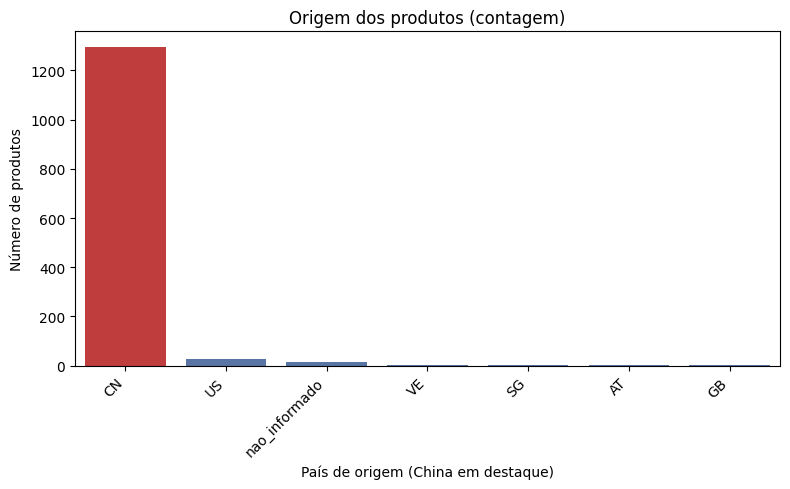

/tmp/ipykernel_38/1069391535.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='percent', data=top_df, palette=colors_top)


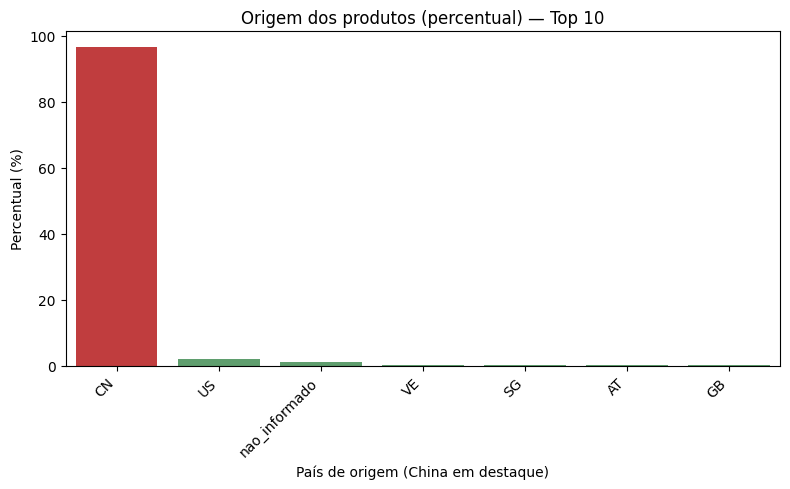

/tmp/ipykernel_38/1069391535.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='group', y='count', data=bin_df, palette=['#D62728','#4C72B0'])


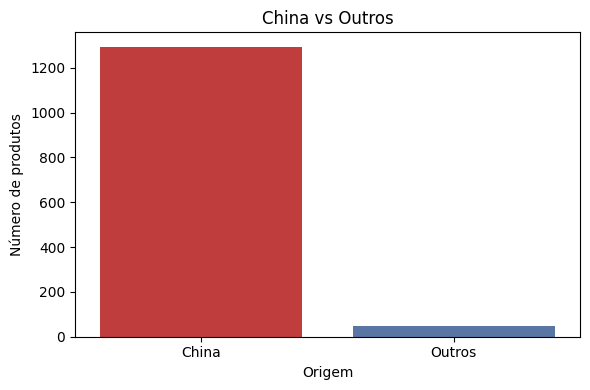

In [ ]:
# Corrigir KeyError: assegurar que a coluna 'country' existe após reset_index
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Se limpos_df já estiver carregado, prosseguir; senão, recarregar
if 'limpos_df' not in globals():
    limpos = pd.read_excel('limpos_final.xlsm', sheet_name=None)
    sheet_names = list(limpos.keys())
    limpos_df = limpos[sheet_names[0]]

col = 'origin_countryFix'
if col in limpos_df.columns:
    origem_counts = limpos_df[col].value_counts(dropna=False)
    origem_pct = (origem_counts / origem_counts.sum() * 100).round(2)

    origem_df = pd.DataFrame({
        'country': origem_counts.index.astype(str),
        'count': origem_counts.values
    })
    origem_df = origem_df.merge(
        pd.DataFrame({'country': origem_pct.index.astype(str), 'percent': origem_pct.values}),
        on='country', how='left'
    )

    # Normalizar labels para identificar China
    origem_df['country_norm'] = origem_df['country'].astype(str).str.strip().str.upper()
    origem_df['is_china'] = origem_df['country_norm'].isin(['CN','CHINA'])

    # Reordenar: China primeiro, depois restante por contagem desc
    origem_df = origem_df.sort_values(['is_china','count'], ascending=[False, False])

    # Gráfico 1: contagem, destacando China
    plt.figure(figsize=(8,5))
    colors = ['#D62728' if is_ch else '#4C72B0' for is_ch in origem_df['is_china']]
    sns.barplot(x='country', y='count', data=origem_df, palette=colors)
    plt.xlabel('País de origem (China em destaque)')
    plt.ylabel('Número de produtos')
    plt.title('Origem dos produtos (contagem)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Gráfico 2: percentual (Top 10), destacando China
    top_df = origem_df.head(min(10, len(origem_df)))
    plt.figure(figsize=(8,5))
    colors_top = ['#D62728' if is_ch else '#55A868' for is_ch in top_df['is_china']]
    sns.barplot(x='country', y='percent', data=top_df, palette=colors_top)
    plt.xlabel('País de origem (China em destaque)')
    plt.ylabel('Percentual (%)')
    plt.title('Origem dos produtos (percentual) — Top 10')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Gráfico 3: China vs Outros
    china_count = origem_df.loc[origem_df['is_china'], 'count'].sum()
    others_count = origem_df.loc[~origem_df['is_china'], 'count'].sum()
    bin_df = pd.DataFrame({'group':['China','Outros'], 'count':[china_count, others_count]})
    plt.figure(figsize=(6,4))
    sns.barplot(x='group', y='count', data=bin_df, palette=['#D62728','#4C72B0'])
    plt.xlabel('Origem')
    plt.ylabel('Número de produtos')
    plt.title('China vs Outros')
    plt.tight_layout()
    plt.show()
else:
    print('Coluna origin_countryFix não encontrada no DataFrame.')

Pronto\. Foram gerados três gráficos destacando a China no eixo X:
\- Barras por contagem de produtos por país com China em destaque\.
\- Barras por percentual \(Top 10\) com China em destaque\.
\- Comparativo binário China vs Outros\.

> Com base na imagem fornecida e na estrutura do seu dataset, os dados apresentados no infográfico foram calculados a partir de colunas específicas que você já possui\.

Aqui está a extração exata dos dados do gráfico cruzados com o seu dataset para você estruturar as suas fórmulas:

\-\-\-

\#\# 1\. Métrica: Concentração de Origem \(96,4% China\)

O gráfico de rosca e o primeiro bloco destacam que \*\*96,4% dos produtos vêm da China\*\*, representando \*\*1\.516 de um total de 1\.556 produtos\*\*\.

\* \*\*Coluna do Dataset Utilizada:\*\* \`origin\_countryFix\` \(onde constam valores como \`"CN"\` para China\)\.
\* \*\*Lógica para a Fórmula:\*\*
\* \*\*Total de Produtos \(Denominador\):\*\* Contagem total de linhas do dataset: \`COUNT\(product\_id\)\`\.
\* \*\*Produtos da China \(Numerador\):\*\* Contagem de linhas onde o país é igual a "CN": \`COUNTIF\(origin\_countryFix, "CN"\)\`\.
\* \*\*Cálculo da Porcentagem:\*\* $\\frac\{1516\}\{1556\} \\times 100 = 96,41\\%$



\-\-\-

\#\# 2\. Métrica: Países Destino Médios \(40,5\)

O segundo bloco indica uma média de \*\*40,5 países destino\*\*, com um teto de \*\*até 140 países por produto\*\*\.

\* \*\*Coluna do Dataset Utilizada:\*\* \`countries\_shipped\_to\` \(que armazena a quantidade de países para os quais o produto pode ser enviado\)\.
\* \*\*Lógica para a Fórmula:\*\*
\* \*\*Média \(40,5\):\*\* Média aritmética simples de todos os valores dessa coluna: \`AVERAGE\(countries\_shipped\_to\)\`\.
\* \*\*Máximo \(Até 140\):\*\* O valor máximo encontrado nessa mesma coluna em todo o dataset: \`MAX\(countries\_shipped\_to\)\`\.



\-\-\-

\#\# 3\. Métrica: Distância Média \(~9\.000 km\)

O terceiro bloco mostra uma distância aproximada de \*\*~9\.000 km\*\* representando o impacto do transporte na cadeia de abastecimento\.

\* \*\*Como replicar:\*\* Como o seu dataset é focado em e\-commerce \(provavelmente dados da Wish\), essa métrica é uma constante calculada externamente com base na distância geopolítica média de transporte marítimo/aéreo entre a \*\*China \(CN\)\*\* e o país destino final do estudo de caso \(provavelmente Portugal ou algum país da Europa Ocidental, dado o idioma do slide\)\.
\* \*\*Lógica para a Fórmula:\*\* No seu dataset, você pode criar uma coluna condicional baseada em \`origin\_countryFix\`\. Se for \`"CN"\`, atribui\-se o peso de \`9000\` km para calcular a pegada ecológica de transporte \(geralmente multiplicada por \`units\_sold\` para ver o impacto total de deslocamento de mercadorias\)\.

\-\-\-

\#\#\# Resumo das colunas que você vai isolar para trabalhar:

1\. \`origin\_countryFix\` \(Para a rosca de 96,4%\)
2\. \`countries\_shipped\_to\` \(Para a média de 40,5 e máximo de 140\)

In [ ]:
# Calcular as três métricas solicitadas a partir de limpos_df
import pandas as pd

# Garantir que limpos_df está carregado
if 'limpos_df' not in globals():
    limpos = pd.read_excel('limpos_final.xlsm', sheet_name=None)
    sheet_names = list(limpos.keys())
    limpos_df = limpos[sheet_names[0]]

results = {}

# 1) Concentração de origem (China)
if 'origin_countryFix' in limpos_df.columns:
    total_produtos = len(limpos_df)
    # considerar 'CN' e variação 'China'
    origin_norm = limpos_df['origin_countryFix'].astype(str).str.strip().str.upper()
    china_count = (origin_norm.isin(['CN','CHINA'])).sum()
    china_pct = (china_count / total_produtos * 100) if total_produtos > 0 else 0
    results['total_produtos'] = int(total_produtos)
    results['china_produtos'] = int(china_count)
    results['china_percent'] = round(china_pct, 2)

# 2) Países destino médios e máximo
if 'countries_shipped_to' in limpos_df.columns:
    cst = pd.to_numeric(limpos_df['countries_shipped_to'], errors='coerce')
    media_cst = cst.mean()
    max_cst = cst.max()
    results['media_countries_shipped_to'] = round(float(media_cst), 2) if pd.notna(media_cst) else None
    results['max_countries_shipped_to'] = int(max_cst) if pd.notna(max_cst) else None

# 3) Distância média ~9000 km para itens de origem CN (constante aplicada)
# Criaremos uma coluna estimada de distancia_km assumindo 9000 km para CN e NaN para outros
if 'origin_countryFix' in limpos_df.columns:
    limpos_df['distancia_km_est'] = limpos_df['origin_countryFix'].astype(str).str.strip().str.upper().apply(
        lambda x: 9000 if x in ['CN','CHINA'] else None
    )

results

{'total_produtos': 1341,
 'china_produtos': 1294,
 'china_percent': 96.5,
 'media_countries_shipped_to': 40.68,
 'max_countries_shipped_to': 140}

Métricas calculadas no dataset atual:
\- Total de produtos: 1341
\- Produtos da China: 1294 \(96\.5%\)
\- Países destino médios: 40\.68
\- Máximo de países destino: 140

Também criei a coluna distancia\_km\_est com 9000 km para itens de origem CN/China\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=acb13dac-3e3d-49c3-81b9-b25c403473b5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>